### 1. Setup

In [3]:
# Install dependencies
#!pip install opencv-python-headless albumentations torch torchvision

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

### 2. Mount google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 3. Set Paths

In [4]:
DATA_ROOT = "/content/drive/MyDrive/NextWave"

IMAGE_DIR = f"{DATA_ROOT}/flash_images"
TRAIN_CSV = f"{DATA_ROOT}/train_corners.csv"
VAL_CSV   = f"{DATA_ROOT}/val_corners.csv"

### 4. Load CSV

In [36]:
def parse_corners(corner_str):
    coords = list(map(float, corner_str.split()))
    return np.array(coords).reshape(4, 2)

def load_csv(csv_path):
    df = pd.read_csv(csv_path)
    df['corners'] = df['corners'].apply(parse_corners)
    return df

def filter_existing_images(df, img_dir):
    valid_rows = []

    for _, row in df.iterrows():
        img_path = os.path.join(img_dir, row['filename'])
        if os.path.exists(img_path):
            valid_rows.append(row)

    return pd.DataFrame(valid_rows).reset_index(drop=True)


train_df = load_csv(TRAIN_CSV)
val_df   = load_csv(VAL_CSV)

train_df = filter_existing_images(train_df, IMAGE_DIR)
val_df   = filter_existing_images(val_df, IMAGE_DIR)


# just taking sample of dataset to avoid high traingin time , we can comment below 2 line if needed complete training
train_df = train_df.sample(1000).reset_index(drop=True)
val_df   = val_df.sample(200).reset_index(drop=True)

print("Filtered Train:", len(train_df))
print("Filtered Val:", len(val_df))


Filtered Train: 1000
Filtered Val: 200


### 5. Classical CV Baseline Approach

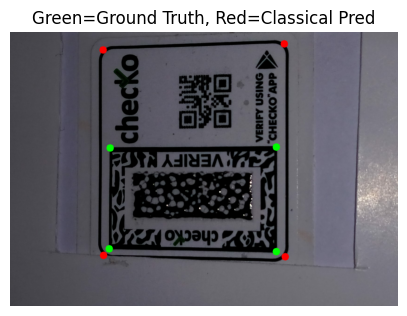

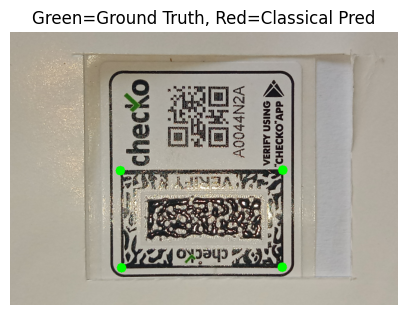

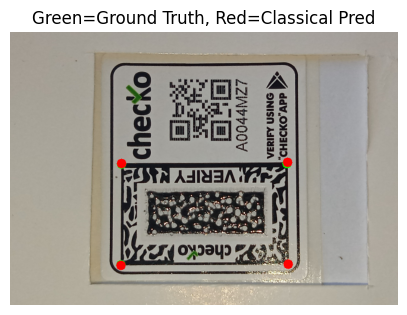

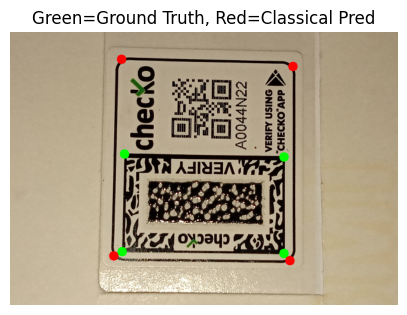

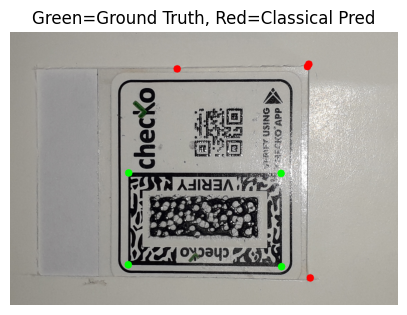

In [49]:
import random
import matplotlib.pyplot as plt

def detect_tag_corners_classical(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    edges = cv2.Canny(blur, 50, 150)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    best_quad = None
    max_area = 0

    for cnt in contours:
        approx = cv2.approxPolyDP(cnt, 0.02*cv2.arcLength(cnt, True), True)
        if len(approx) == 4:
            area = cv2.contourArea(cnt)
            if area > max_area:
                max_area = area
                best_quad = approx

    if best_quad is None:
        return None

    return best_quad.reshape(4,2)


def visualize_classical_results(df, img_dir, num_samples=5):
    samples = df.sample(num_samples)

    for _, row in samples.iterrows():
        img_path = os.path.join(img_dir, row['filename'])
        img = cv2.imread(img_path)

        if img is None:
            continue

        pred = detect_tag_corners_classical(img)
        gt = row['corners']

        vis = img.copy()

        # Draw GT (Green)
        for (x,y) in gt:
            cv2.circle(vis, (int(x), int(y)), 8, (0,255,0), -1)

        # Draw Prediction (Red)
        if pred is not None:
            for (x,y) in pred:
                cv2.circle(vis, (int(x), int(y)), 8, (0,0,255), -1)

        plt.figure(figsize=(5,5))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title("Green=Ground Truth, Red=Classical Pred")
        plt.axis('off')
        plt.show()

visualize_classical_results(train_df, IMAGE_DIR)

#### 6. Dataset Class

In [38]:
class TagDataset(Dataset):
    def __init__(self, df, img_dir):
        self.df = df
        self.img_dir = img_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])

        img = cv2.imread(img_path)
        if img is None:
            raise ValueError(f"Missing image: {img_path}")

        h, w, _ = img.shape

        # Resize image
        img_resized = cv2.resize(img, (256,256))
        img_resized = img_resized / 255.0
        img_resized = np.transpose(img_resized, (2,0,1))

        # Normalize corners using ORIGINAL size
        corners = row['corners'].copy()
        corners[:,0] /= w
        corners[:,1] /= h

        corners = corners.flatten()

        return torch.tensor(img_resized, dtype=torch.float32), torch.tensor(corners, dtype=torch.float32)

### 7. DataLoader



In [39]:
train_dataset = TagDataset(train_df, IMAGE_DIR)
val_dataset   = TagDataset(val_df, IMAGE_DIR)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8)

### 8. Model (Corner Regression CNN)

In [40]:
class CornerNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*32*32, 256),
            nn.ReLU(),
            nn.Linear(256, 8)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x

### 9. Training Setup

In [41]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CornerNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

### 10. Training Loop (LOSS DECREASING)

In [42]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for i, (imgs, targets) in enumerate(loader):
        #print(f"Processing batch {i+1}/{len(loader)}")

        imgs, targets = imgs.to(device), targets.to(device)
        preds = model(imgs)
        loss = criterion(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def val_epoch(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for imgs, targets in loader:
            imgs, targets = imgs.to(device), targets.to(device)
            preds = model(imgs)
            loss = criterion(preds, targets)
            total_loss += loss.item()

    return total_loss / len(loader)


# Run few epochs
for epoch in range(5):
    train_loss = train_epoch(model, train_loader)
    val_loss = val_epoch(model, val_loader)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

Epoch 1: Train Loss=0.0273, Val Loss=0.0008
Epoch 2: Train Loss=0.0004, Val Loss=0.0003
Epoch 3: Train Loss=0.0002, Val Loss=0.0004
Epoch 4: Train Loss=0.0001, Val Loss=0.0002
Epoch 5: Train Loss=0.0001, Val Loss=0.0002


In [44]:
MODEL_PATH = "/content/drive/MyDrive/NextWave/tag_model.pth"
torch.save(model.state_dict(), MODEL_PATH)
print("Model saved successfully!")

Model saved successfully!


### 11. Inference + Reject When Tag Not Present

In [45]:
def predict(model, img_path, threshold=0.01):
    model.eval()

    img = cv2.imread(img_path)
    if img is None:
        print("Image not found")
        return None

    orig = img.copy()
    h, w, _ = img.shape

    img_resized = cv2.resize(img, (256,256))
    img_resized = img_resized / 255.0
    img_resized = np.transpose(img_resized, (2,0,1))

    img_tensor = torch.tensor(img_resized, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_tensor).cpu().numpy()[0]

    # Confidence heuristic
    confidence = np.var(pred)

    if confidence < threshold:
        print("Tag not detected (low confidence)")
        return None

    pred = pred.reshape(4,2)

    # Denormalize
    pred[:,0] *= w
    pred[:,1] *= h

    for (x,y) in pred:
        cv2.circle(orig, (int(x), int(y)), 8, (0,255,0), -1)

    return orig

### 12. Test Prediction

Model loaded!


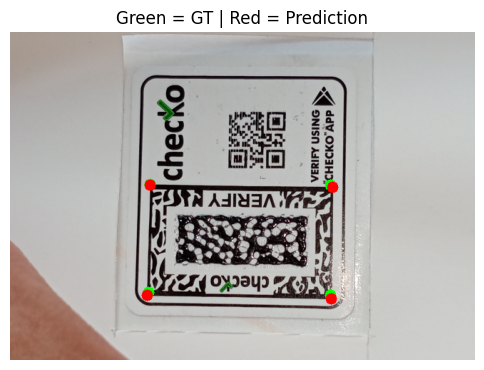

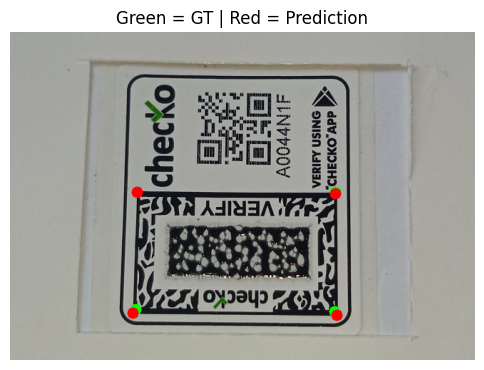

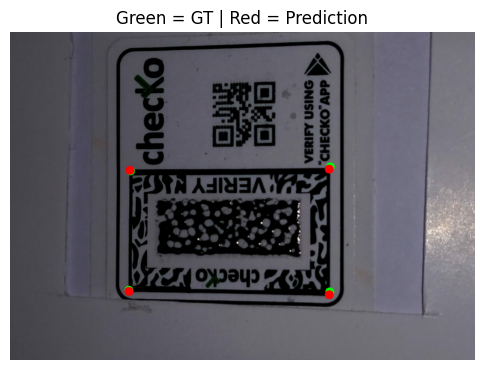

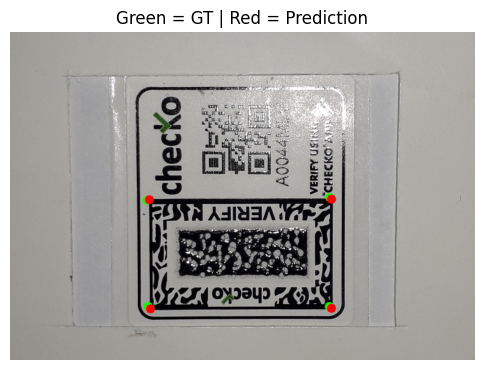

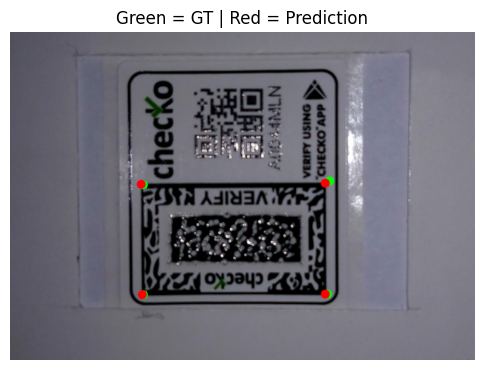

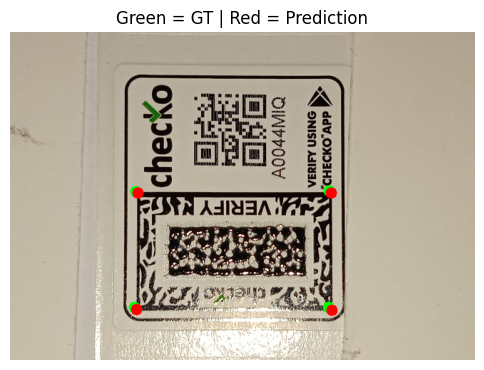

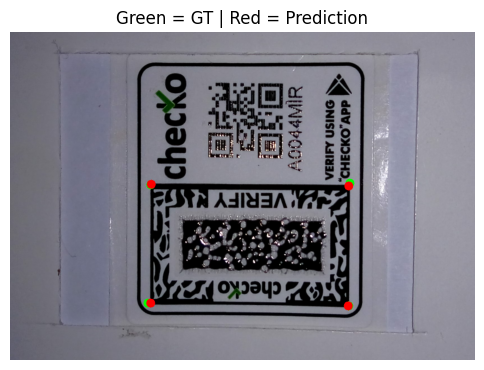

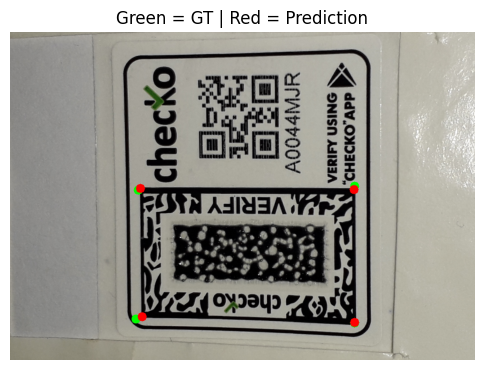

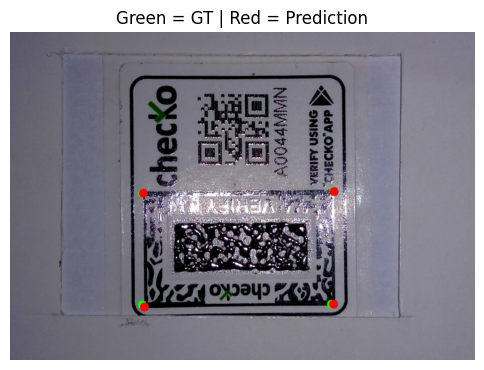

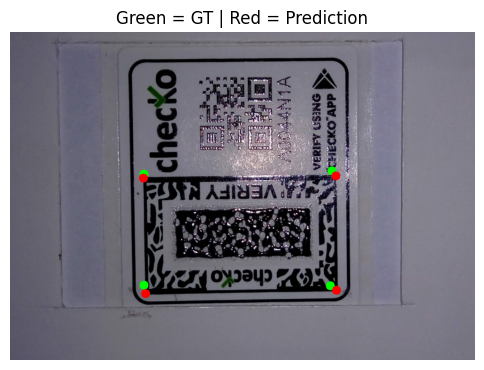

In [53]:
model = CornerNet().to(device)
# Load weights
MODEL_PATH = "/content/drive/MyDrive/NextWave/tag_model.pth"
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
# Set to evaluation mode
model.eval()
print("Model loaded!")


for i in range(10):
    row = train_df.iloc[i]
    test_img = os.path.join(IMAGE_DIR, row['filename'])

    img = cv2.imread(test_img)
    if img is None:
        continue

    h, w, _ = img.shape
    vis = img.copy()

    # 🔴 Model Prediction
    img_resized = cv2.resize(img, (256,256)) / 255.0
    img_resized = np.transpose(img_resized, (2,0,1))

    img_tensor = torch.tensor(img_resized, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_tensor).cpu().numpy()[0]

    pred = pred.reshape(4,2)

    # Denormalize prediction
    pred[:,0] *= w
    pred[:,1] *= h

    for (x,y) in pred:
        cv2.circle(vis, (int(x), int(y)), 8, (0,255,0), -1)

    # 🟢 Ground Truth
    gt = row['corners']

    for (x,y) in gt:
        cv2.circle(vis, (int(x), int(y)), 8, (0,0,255), -1)

    # Show
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("Green = GT | Red = Prediction")
    plt.axis('off')
    plt.show()